# **IMPORTS**

In [3]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [4]:
df = pd.read_csv("/content/Ames Housing Price.csv")

print("Dataset Shape:", df.shape)

Dataset Shape: (1460, 81)


In [5]:
# BASIC CLEANING + TARGET TRANSFORM
df.drop("Id", axis=1, inplace=True)

df["SalePrice"] = np.log1p(df["SalePrice"])

# **EDA**

        MSSubClass  LotFrontage        LotArea  OverallQual  OverallCond  \
count  1460.000000  1201.000000    1460.000000  1460.000000  1460.000000   
mean     56.897260    70.049958   10516.828082     6.099315     5.575342   
std      42.300571    24.284752    9981.264932     1.382997     1.112799   
min      20.000000    21.000000    1300.000000     1.000000     1.000000   
25%      20.000000    59.000000    7553.500000     5.000000     5.000000   
50%      50.000000    69.000000    9478.500000     6.000000     5.000000   
75%      70.000000    80.000000   11601.500000     7.000000     6.000000   
max     190.000000   313.000000  215245.000000    10.000000     9.000000   

         YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1   BsmtFinSF2  ...  \
count  1460.000000   1460.000000  1452.000000  1460.000000  1460.000000  ...   
mean   1971.267808   1984.865753   103.685262   443.639726    46.549315  ...   
std      30.202904     20.645407   181.066207   456.098091   161.319273  ..

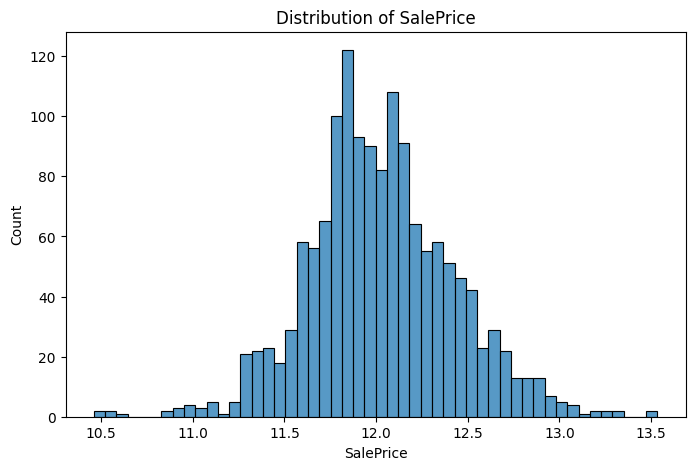

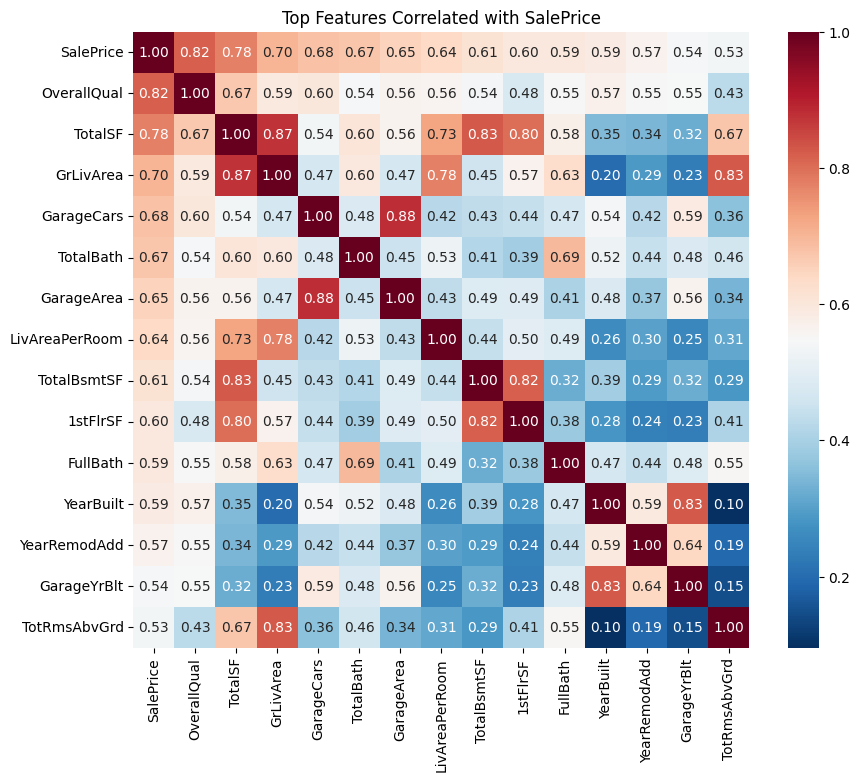

In [17]:
print(df.describe())

plt.figure(figsize=(8,5))
sns.histplot(df["SalePrice"], bins=50)
plt.title("Distribution of SalePrice")
plt.show()

# correlation with SalePrice
corr = df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)

# top correlated features
top_corr = corr.head(15).index

plt.figure(figsize=(10,8))
sns.heatmap(
    df[top_corr].corr(),
    annot=True,
    cmap="RdBu_r",
    fmt=".2f",
    square=True
)

plt.title("Top Features Correlated with SalePrice")
plt.show()

# **FEATURE ENGINEERING**

In [7]:
def feature_engineering(df):
    df = df.copy()

    df["TotalSF"] = df["1stFlrSF"] + df["2ndFlrSF"] + df["TotalBsmtSF"]
    df["TotalBath"] = df["FullBath"] + 0.5*df["HalfBath"] + df["BsmtFullBath"] + 0.5*df["BsmtHalfBath"]
    df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
    df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]
    df["HasGarage"] = (df["GarageArea"] > 0).astype(int)
    df["HasFireplace"] = (df["Fireplaces"] > 0).astype(int)
    df["TotalPorchSF"] = df[["OpenPorchSF","EnclosedPorch","3SsnPorch","ScreenPorch"]].sum(axis=1)
    df["LivAreaPerRoom"] = df["GrLivArea"] / (df["TotRmsAbvGrd"] + 1)

    return df

df = feature_engineering(df)

# **SPLIT DATA**

In [8]:
x = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# **PREPROCESSING**

In [9]:
# numeric columns
num_cols = x.select_dtypes(include=np.number).columns

# categorical columns
cat_cols = x.select_dtypes(include="object").columns


# fill missing values in numeric data
num_pipe = SimpleImputer(strategy="median")
x_train[num_cols] = num_pipe.fit_transform(x_train[num_cols])
x_test[num_cols] = num_pipe.transform(x_test[num_cols])


# fill missing values in categorical data
cat_pipe = SimpleImputer(strategy="most_frequent")
x_train[cat_cols] = cat_pipe.fit_transform(x_train[cat_cols])
x_test[cat_cols] = cat_pipe.transform(x_test[cat_cols])


# convert categories into numbers
x_train = pd.get_dummies(x_train)
x_test = pd.get_dummies(x_test)


# make train and test columns match
x_train, x_test = x_train.align(x_test, join="left", axis=1, fill_value=0)


# scale features
scaler = RobustScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# **Models**

In [10]:
models = {
    "Ridge": Ridge(),
    "Lasso": Lasso(alpha=0.001),
    "ElasticNet": ElasticNet(),
    "RF": RandomForestRegressor(n_estimators=200),
    "GB": GradientBoostingRegressor()
}

results = []

for name, model in models.items():
    model.fit(x_train, y_train)
    pred = model.predict(x_test)

    results.append([
        name,
        r2_score(y_test, pred),
        np.sqrt(mean_squared_error(y_test, pred)),
        mean_absolute_error(y_test, pred)
    ])

# **Results**

In [11]:
results_df = pd.DataFrame(results, columns=["Model","R2","RMSE","MAE"])
results_df = results_df.sort_values("R2", ascending=False)

print(results_df)

        Model        R2      RMSE       MAE
0       Ridge  0.910907  0.128940  0.090050
1       Lasso  0.903263  0.134359  0.091385
4          GB  0.898637  0.137534  0.089073
3          RF  0.884985  0.146503  0.096741
2  ElasticNet  0.009280  0.429976  0.333016


# **Stacking**

In [12]:
stack = StackingRegressor(
    estimators=[
        ("rf", RandomForestRegressor()),
        ("gb", GradientBoostingRegressor())
    ],
    final_estimator=Ridge()
)

stack.fit(x_train, y_train)

stack_pred = stack.predict(x_test)

print("Stacking R2:", r2_score(y_test, stack_pred))

Stacking R2: 0.8993999360361796


# **Model Comparison**

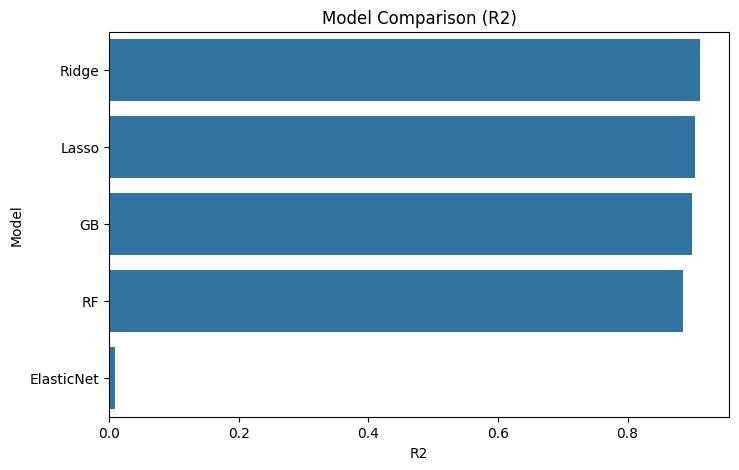

In [13]:
plt.figure(figsize=(8,5))
sns.barplot(x="R2", y="Model", data=results_df)
plt.title("Model Comparison (R2)")
plt.show()

# **Predictions vs Actual**

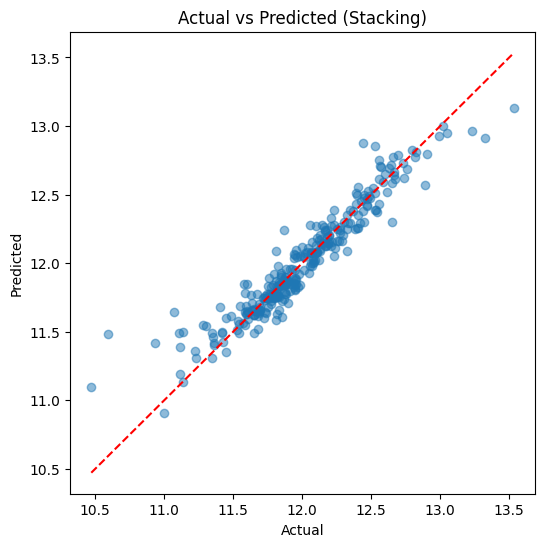

In [14]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, stack_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.title("Actual vs Predicted (Stacking)")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

# **Error Distribution**

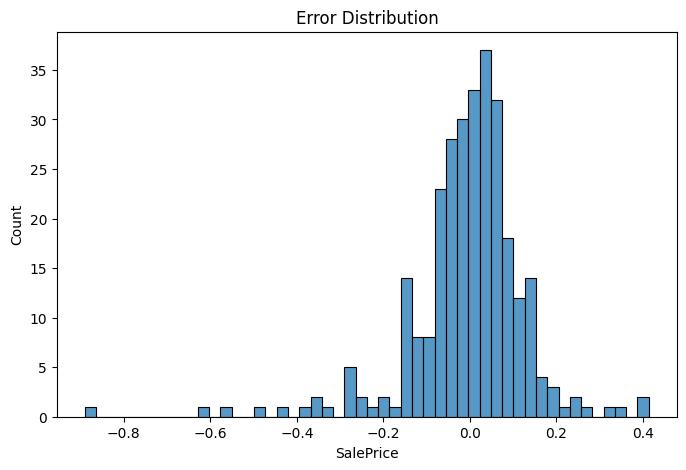

In [15]:
errors = y_test - stack_pred

plt.figure(figsize=(8,5))
sns.histplot(errors, bins=50)
plt.title("Error Distribution")
plt.show()

# **SAVE MODEL**

In [16]:
import joblib
joblib.dump(stack, "ames_model.pkl")

['ames_model.pkl']